## NMD Models: Economic Theory Model

This notebook shows how to develop the Economic Value of NMD Benefits and ΔEVE under the interest rate shock.

### Input from other components
| Input | From | Use for |
|---|---|---|
| `jvd beta_2` (The Beta2) | Notebook 04 JVD | β — short-term pass-through |
| `threshold b` (The Beta, now called Gamma) | Notebook 04 Threshold | γ — long-run pass-through |
| `threshold g` (The Gap, now called Alpha) | Notebook 04 Threshold | α — bank spread |

### Core idea
The Bank always earns rate of `r` but repay to their customer at rate of `d`. So, the `d < r` as always. This is a spread that implicit benefit of NMD Model. The benefit is Present Value (PV) of cashflow `D_t × (r_t − d_t)` over time horizon.

### Cashflow definition
Using the **spread-minus-shock** to meansure the true sensitivity.
```
CF_t = D_t × ((r_t − shock) − d_t)
```
Removing (stripping out) the `shock` level from the discount rate `r` ensures that the calculated cash flow (CF) reflects the true economic benefit of NMDs (Non-Maturity Deposits) over their funding cost rather than showing a windfall gain driven simply by higher interest rates.

In [ ]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [16]:
# Import libraries
import warnings
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.economic_theory import calibrate_all, simulate_paths, compute_eve
from src.plot_function import plot_economic_theory_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [17]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract information
market_rate = df["market_rate"]
deposit_rate = df["deposit_rate"]
cds_spread = df["cds_spread"]
balance = df["balance"]

# Show
df[["market_rate", "deposit_rate", "cds_spread", "balance"]].describe()

,market_rate,deposit_rate,cds_spread,balance
count,150.000,150.000,150.000,150.000
mean,0.049,0.009,66.587,5185.951
std,0.007,0.002,25.913,335.315
min,0.028,0.004,31.275,4523.784
25%,0.044,0.008,48.204,4880.310
50%,0.048,0.009,59.934,5256.091
75%,0.054,0.010,82.366,5414.796
max,0.064,0.012,184.451,6083.954


In [18]:
# Import related models
# Import beta model
with open("../model/beta_model.pkl", "rb") as file:
    beta_model = pickle.load(file)

# Import threshold model
with open("../model/threshold_model.pkl", "rb") as file:
    threshold_model = pickle.load(file)

# Import JVD Model
with open("../model/jvd_model.pkl", "rb") as file:
    jvd_model = pickle.load(file)

In [19]:
# Get upstream parameters
gamma = beta_model["beta"] #Beta: Long-run pass-through (Now called Gamma)
alpha = threshold_model["g"] #Bank spread (Now called Alpha)
beta_2 = jvd_model["beta_2"] #Beta2: Short-term pass-through (Now called Beta)

# Show
print("=" * 60)
print(f"{"Gamma (Long-run pass-through)":<{35}}: {gamma:.4f} [Beta Regression]")
print(f"{"Alpha (Bank spread)":<{35}}: {alpha:.4f} [Threshold Model]")
print(f"{"Beta2 (Short-term pass-through)":<{35}}: {beta_2:.4f} [JVD Model]")
print("=" * 60)

Gamma (Long-run pass-through)      : 0.2072 [Beta Regression]
Alpha (Bank spread)                : 0.0008 [Threshold Model]
Beta2 (Short-term pass-through)    : 0.0797 [JVD Model]


In [20]:
# Carlibration
params = calibrate_all(
    market_rate = market_rate,
    deposit_rate = deposit_rate,
    balance = balance,
    cds_spread = cds_spread,
    beta_2 = beta_2,
    gamma = gamma,
    alpha = alpha
)

# Result
print("=" * 60)
print("Rate dynamics")
print(f"{"mu":<{8}}: {params['rate']['mu']:.4f}")
print(f"{"sigma_r":<{8}}: {params['rate']['sigma_r']:.4f}")
print(f"{"r0":<{8}}: {params['rate']['r0']:.2%}")
print("=" * 60)
print("Deposit rate dynamics")
print(f"{"kappa":<{8}}: {params['deposit']['kappa']:.4f}")
print(f"{"sigma_d":<{8}}: {params['deposit']['sigma_d']:.4f}")
print(f"{"d0":<{8}}: {params['deposit']['d0']:.2%}")
print("=" * 60)
print("Volume dynamics")
print(f"{"phi":<{8}}: {params['volume']['phi']:.4f}")
print(f"{"lambda":<{8}}: {params['volume']['lam']:.4f}")
print(f"{"theta":<{8}}: {params['volume']['theta']:.4f}")
print(f"{"D0":<{8}}: {params['volume']['D0']:,.1f} MB")
print("=" * 60)
print("CDS dynamics")
print(f"{"eta":<{8}}: {params['cds']['eta']:.4f}")
print(f"{"rho":<{8}}: {params['cds']['rho']:.4f}")
print(f"{"cds0":<{8}}: {params['cds']['cds0']:.1f} bps")
print("=" * 60)
print("Cholesky correlation matrix")
pd.DataFrame(
    params["chol"],
    index = ["r", "d", "D", "CDS"],
    columns = ["r", "d", "D", "CDS"]
)

Rate dynamics
mu      : 0.0752
sigma_r : 0.0039
r0      : 4.55%
Deposit rate dynamics
kappa   : -0.0580
sigma_d : 0.0006
d0      : 0.73%
Volume dynamics
phi     : 0.0025
lambda  : -0.7094
theta   : -0.0035
D0      : 5,039.6 MB
CDS dynamics
eta     : 0.5568
rho     : 0.1353
cds0    : 37.8 bps
Cholesky correlation matrix


,r,d,D,CDS
r,1.000,0.000,0.000,0.000
d,-0.020,1.000,0.000,0.000
D,-0.004,0.007,1.000,0.000
CDS,-0.226,-0.289,-0.053,0.929


In [21]:
# Export
with open("../model/dynamics_model.pkl", "wb") as file:
    pickle.dump(params, file)

In [22]:
## Simulation of Base & Stressed
N_PATHS = 1000
N_MONTHS = 60
RATE_SHOCK = 0.02  #+200bps

sim_kwargs = dict(
    params = params,
    beta_2 = beta_2,
    gamma = gamma,
    alpha = alpha,
    n_paths = N_PATHS,
    n_months = N_MONTHS
)

paths_base = simulate_paths(**sim_kwargs, rate_shock = 0.0, seed = 42)
paths_stressed = simulate_paths(**sim_kwargs, rate_shock = RATE_SHOCK, seed = 42)

# Result
print("=" * 60)
print(f"{"Paths simulated":<{20}}: {N_PATHS}")
print(f"{"Horizon":<{20}}: {N_MONTHS} months")
print(f"{"Rate shock":<{20}}: +{RATE_SHOCK*100:.0f}bps")
print(f"{"Base mean r (t=1)":<{20}}: {paths_base['r'][:, 0].mean():.2%}")
print(f"{"Stress mean r (t=1)":<{20}}: {paths_stressed['r'][:, 0].mean():.2%}")
print("=" * 60)

Paths simulated     : 1000
Horizon             : 60 months
Rate shock          : +2bps
Base mean r (t=1)   : 4.55%
Stress mean r (t=1) : 6.55%


In [ ]:
# EVE
eve_base = compute_eve(paths_base)
eve_stressed = compute_eve(paths_stressed)

# Result
print("=" * 60)
print("Base scenario")
print(f"{"EVE":<{10}}: {eve_base['eve']:,.2f} MB")
print(f"{"P5 EVE":<{10}}: {eve_base['pv_p5']:,.2f} MB")
print(f"{"P95 EVE":<{10}}: {eve_base['pv_p95']:,.2f} MB")
print("=" * 60)
print("Stressed scenario (+200bps)")
print(f"{"EVE":<{10}}: {eve_stressed['eve']:,.2f} MB")
print(f"{"P5 EVE":<{10}}: {eve_stressed['pv_p5']:,.2f} MB")
print(f"{"P95 EVE":<{10}}: {eve_stressed['pv_p95']:,.2f} MB")
print("=" * 60)

Base scenario
EVE       : 9,504.69 MB
P5 EVE    : 3,310.41 MB
P95 EVE   : 16,510.61 MB
Stressed scenario (+200bps)
EVE       : 8,290.37 MB
P5 EVE    : 2,078.92 MB
P95 EVE   : 14,932.81 MB


In [24]:
# Compute ΔEVE
"""
Compute ΔEVE as the change in economic value under interest rate shock.
    ΔEVE = EVE(stressed) - EVE(base)
    Negative ΔEVE means the value of NMD benefits decreases when rates rise.
    Primary IRRBB metric under BCBS 368 / EBA Guidelines.
"""
delta = eve_stressed["eve"] - eve_base["eve"]

# Result
print("=" * 60)
print(f"{"ΔEVE":<{10}}: {delta:,.2f} MB")
print(f"{"ΔEVE%":<{10}}: {delta / abs(eve_base["eve"]):.2%}")
print("=" * 60)

ΔEVE      : -1,214.31 MB
ΔEVE%     : -12.78%


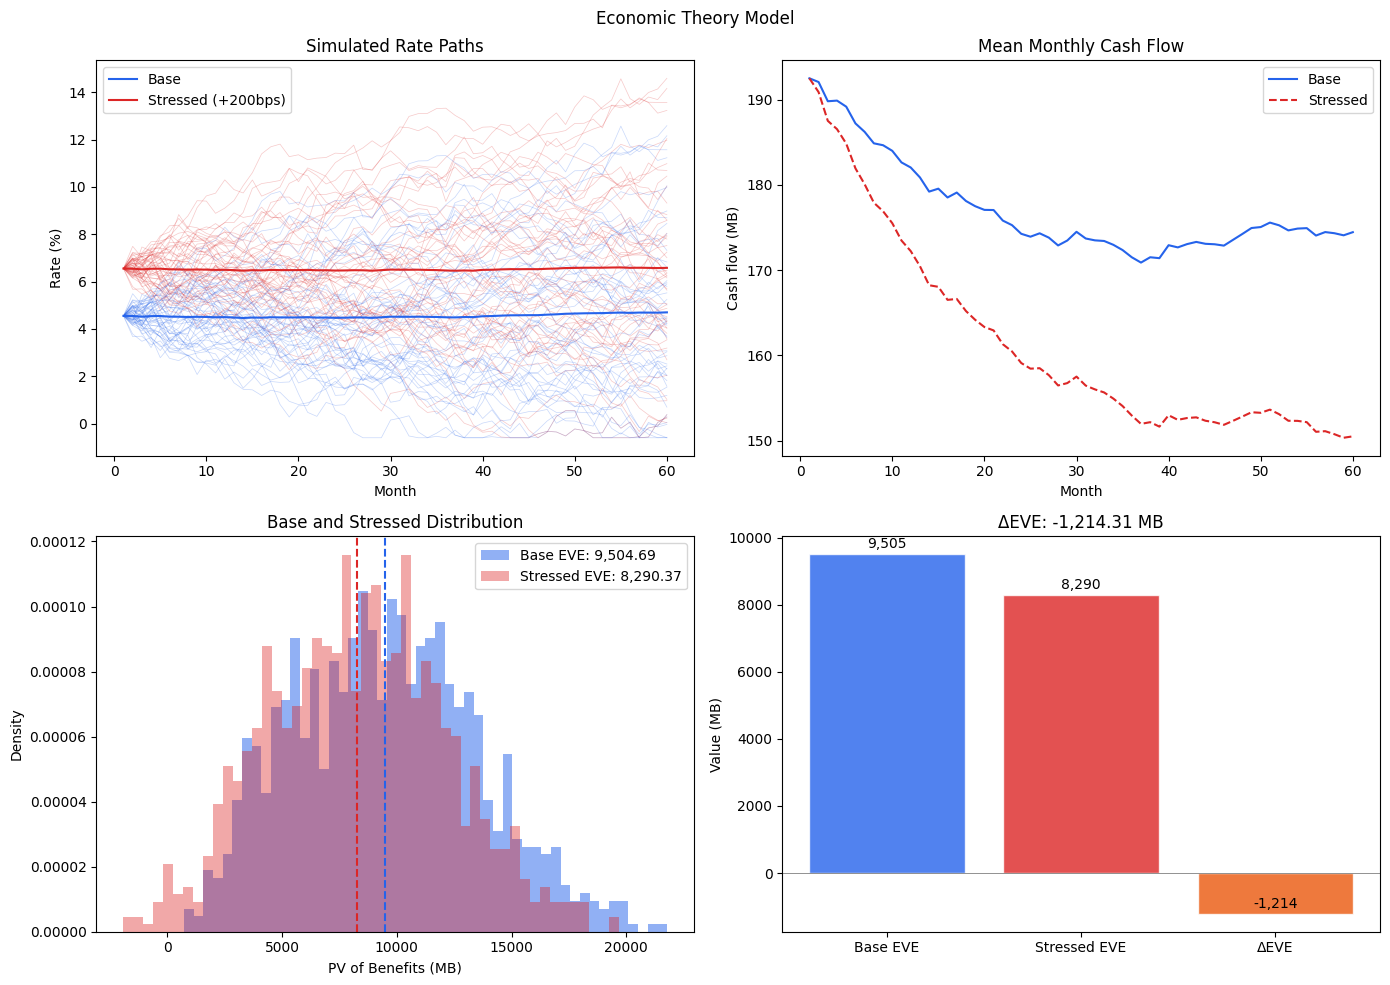

In [25]:
# Plot visualise results
plot_economic_theory_results(
    paths_base = paths_base,
    paths_stressed = paths_stressed,
    eve_base = eve_base,
    eve_stressed = eve_stressed,
    delta_eve = delta,
    n_plot_paths = 50
)